In [1]:
import joblib
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [2]:
X_train_processed = joblib.load("X_train_processed.pkl")
X_test_processed = joblib.load("X_test_processed.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

print(X_train_processed.shape, X_test_processed.shape)

(20000, 43) (5000, 43)


Logistic Regression
Tune C, which controls regularization strength.

In [3]:
lr = LogisticRegression(max_iter=1000)
lr_grid = GridSearchCV(lr, {"C": [0.01, 0.1, 1, 10, 100]}, scoring="roc_auc", cv=5, n_jobs=-1)
lr_grid.fit(X_train_processed, y_train)
print("Best parameters:", lr_grid.best_params_)
print("Best CV ROC-AUC:", lr_grid.best_score_)
tuned_lr = lr_grid.best_estimator_
joblib.dump(tuned_lr, "../models/logistic_regression_tuned.pkl")

Best parameters: {'C': 1}
Best CV ROC-AUC: 0.9675723779210234


['../models/logistic_regression_tuned.pkl']

4. KNN
Tune the number of neighbours, weighting method, and distance metric.

In [4]:
knn = KNeighborsClassifier()
knn_grid = GridSearchCV(
    knn,
    {"n_neighbors": [3, 5, 7, 11, 15, 21], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]},
    scoring="roc_auc", cv=5, n_jobs=-1
)
knn_grid.fit(X_train_processed, y_train)
print("Best parameters:", knn_grid.best_params_)
print("Best CV ROC-AUC:", knn_grid.best_score_)
tuned_knn = knn_grid.best_estimator_
joblib.dump(tuned_knn, "../models/knn_tuned.pkl")

Best parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Best CV ROC-AUC: 0.960651712040635


['../models/knn_tuned.pkl']

5. XGBoost
Tune tree depth, number of trees, learning rate, and subsampling.

In [5]:
# 5. XGBoost
from sklearn.model_selection import train_test_split

# Split the original training data
# 80% will be used for XGBoost tuning
# 20% will be used only for threshold selection

X_xgb_train, X_xgb_validation, y_xgb_train, y_xgb_validation = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_grid = GridSearchCV(
    xgb,
    {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0]
    },
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# IMPORTANT:
# GridSearchCV sees only the XGBoost training portion
xgb_grid.fit(
    X_xgb_train,
    y_xgb_train
)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV ROC-AUC:", xgb_grid.best_score_)

tuned_xgb = xgb_grid.best_estimator_

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV ROC-AUC: 0.9677367691088012


In [6]:
for name, grid in [("Logistic Regression", lr_grid), ("KNN", knn_grid), ("XGBoost", xgb_grid)]:
    results = pd.DataFrame(grid.cv_results_).sort_values("rank_test_score")
    print("\n", name)
    display(results[["params", "mean_test_score", "std_test_score"]].head())


 Logistic Regression


,params,mean_test_score,std_test_score
2,{'C': 1},0.967572,0.002998
3,{'C': 10},0.967465,0.002820
4,{'C': 100},0.967458,0.002824
1,{'C': 0.1},0.967337,0.003377
0,{'C': 0.01},0.965307,0.003648



 KNN


,params,mean_test_score,std_test_score
23,"{'metric': 'manhattan', 'n_neighbors': 21, 'we...",0.960652,0.002966
22,"{'metric': 'manhattan', 'n_neighbors': 21, 'we...",0.960461,0.003228
11,"{'metric': 'euclidean', 'n_neighbors': 21, 'we...",0.960447,0.003833
10,"{'metric': 'euclidean', 'n_neighbors': 21, 'we...",0.960162,0.004112
21,"{'metric': 'manhattan', 'n_neighbors': 15, 'we...",0.958622,0.003032



 XGBoost


,params,mean_test_score,std_test_score
3,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.967737,0.001838
9,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.967729,0.001741
2,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.967611,0.001740
8,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.967590,0.001982
5,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.967480,0.001617


Evaluate tuned models on the untouched test set

In [7]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

Logistic Regression

In [8]:
lr_pred = tuned_lr.predict(X_test_processed)

lr_probability = tuned_lr.predict_proba(
    X_test_processed
)[:, 1]

lr_tuned_results = {
    "Model": "Logistic Regression (Tuned)",
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred),
    "ROC-AUC": roc_auc_score(y_test, lr_probability)
}

print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

lr_tuned_results

Confusion Matrix:
[[3381  285]
 [ 251 1083]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3666
           1       0.79      0.81      0.80      1334

    accuracy                           0.89      5000
   macro avg       0.86      0.87      0.86      5000
weighted avg       0.89      0.89      0.89      5000



{'Model': 'Logistic Regression (Tuned)',
 'Accuracy': 0.8928,
 'Precision': 0.7916666666666666,
 'Recall': 0.8118440779610195,
 'F1 Score': 0.8016284233900814,
 'ROC-AUC': 0.9668995289589247}

KNN

In [9]:
knn_pred = tuned_knn.predict(X_test_processed)

knn_probability = tuned_knn.predict_proba(
    X_test_processed
)[:, 1]

knn_tuned_results = {
    "Model": "KNN (Tuned)",
    "Accuracy": accuracy_score(y_test, knn_pred),
    "Precision": precision_score(y_test, knn_pred),
    "Recall": recall_score(y_test, knn_pred),
    "F1 Score": f1_score(y_test, knn_pred),
    "ROC-AUC": roc_auc_score(y_test, knn_probability)
}

print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

knn_tuned_results

Confusion Matrix:
[[3352  314]
 [ 221 1113]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      3666
           1       0.78      0.83      0.81      1334

    accuracy                           0.89      5000
   macro avg       0.86      0.87      0.87      5000
weighted avg       0.90      0.89      0.89      5000



{'Model': 'KNN (Tuned)',
 'Accuracy': 0.893,
 'Precision': 0.779957953749124,
 'Recall': 0.8343328335832084,
 'F1 Score': 0.8062296269467584,
 'ROC-AUC': 0.9606557196033736}

XGBoost

Compare baseline vs tuned

In [10]:
baseline_comparison_df = pd.read_csv(
    "../reports/model_comparison.csv"
)

baseline_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regrassion,0.8928,0.791667,0.811844,0.801628,0.966900
1,KNN,0.8852,0.770270,0.811844,0.790511,0.941365
2,Decision Tree,0.8734,0.757153,0.773613,0.765295,0.841662
3,Random Forest,0.8908,0.785922,0.811844,0.798673,0.965292
4,XGBoost,0.8888,0.781476,0.809595,0.795287,0.962259


In [11]:
tuned_comparison_df = pd.DataFrame([
    lr_tuned_results,
    knn_tuned_results,
    xgb_tuned_results
])

tuned_comparison_df

NameError: name 'xgb_tuned_results' is not defined

In [ ]:
comparison_tuning = pd.concat(
    [
        baseline_comparison_df,
        tuned_comparison_df
    ],
    ignore_index=True
)

comparison_tuning

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regrassion,0.8928,0.791667,0.811844,0.801628,0.966900
1,KNN,0.8852,0.770270,0.811844,0.790511,0.941365
2,Decision Tree,0.8734,0.757153,0.773613,0.765295,0.841662
3,Random Forest,0.8908,0.785922,0.811844,0.798673,0.965292
4,XGBoost,0.8888,0.781476,0.809595,0.795287,0.962259
5,Logistic Regression (Tuned),0.8928,0.791667,0.811844,0.801628,0.966900
6,KNN (Tuned),0.8930,0.779958,0.834333,0.806230,0.960656
7,XGBoost (Tuned),0.8982,0.798697,0.826837,0.812523,0.967836


calculate the changes automatically

In [ ]:
baseline_tuned = baseline_comparison_df[
    baseline_comparison_df["Model"].isin([
        "Logistic Regrassion",
        "KNN",
        "XGBoost"
    ])
].copy()

baseline_tuned["Model"] = baseline_tuned["Model"].replace({
    "Logistic Regrassion": "Logistic Regression"
})

In [ ]:
tuned_comparison = tuned_comparison_df.copy()

tuned_comparison["Model"] = (
    tuned_comparison["Model"]
    .str.replace(" (Tuned)", "", regex=False)
)

In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

improvement_df = baseline_tuned[
    ["Model"] + metrics
].merge(
    tuned_comparison[
        ["Model"] + metrics
    ],
    on="Model",
    suffixes=("_Baseline", "_Tuned")
)

for metric in metrics:
    improvement_df[f"{metric}_Change"] = (
        improvement_df[f"{metric}_Tuned"]
        - improvement_df[f"{metric}_Baseline"]
    )

improvement_df

,Model,Accuracy_Baseline,Precision_Baseline,Recall_Baseline,F1 Score_Baseline,ROC-AUC_Baseline,Accuracy_Tuned,Precision_Tuned,Recall_Tuned,F1 Score_Tuned,ROC-AUC_Tuned,Accuracy_Change,Precision_Change,Recall_Change,F1 Score_Change,ROC-AUC_Change
0,Logistic Regression,0.8928,0.791667,0.811844,0.801628,0.966900,0.8928,0.791667,0.811844,0.801628,0.966900,0.0000,0.000000,0.000000,0.000000,-1.110223e-16
1,KNN,0.8852,0.770270,0.811844,0.790511,0.941365,0.8930,0.779958,0.834333,0.806230,0.960656,0.0078,0.009688,0.022489,0.015719,1.929038e-02
2,XGBoost,0.8888,0.781476,0.809595,0.795287,0.962259,0.8982,0.798697,0.826837,0.812523,0.967836,0.0094,0.017220,0.017241,0.017236,5.577612e-03


In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

xgb_tuned_train_sizes, xgb_tuned_train_scores, xgb_tuned_validation_scores = learning_curve(
    tuned_xgb,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

In [ ]:
xgb_tuned_train_mean = xgb_tuned_train_scores.mean(axis=1)

xgb_tuned_validation_mean = xgb_tuned_validation_scores.mean(axis=1)

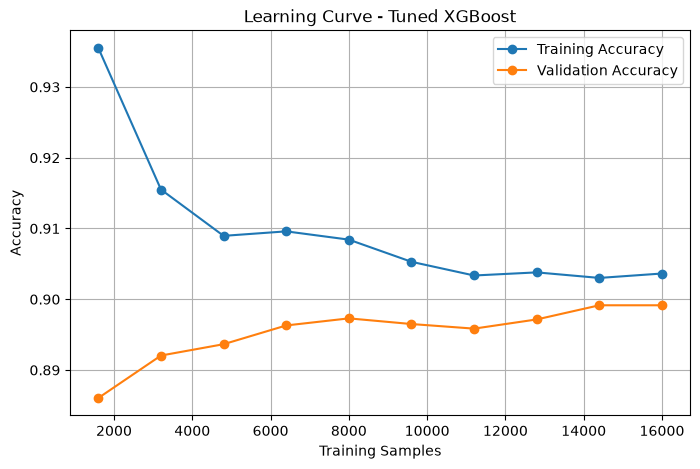

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    xgb_tuned_train_sizes,
    xgb_tuned_train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    xgb_tuned_train_sizes,
    xgb_tuned_validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")

plt.title("Learning Curve - Tuned XGBoost")

plt.legend()
plt.grid()

plt.show()

Tuned Logistic Regression learning curve

In [ ]:
lr_tuned_train_sizes, lr_tuned_train_scores, lr_tuned_validation_scores = learning_curve(
    tuned_lr,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

In [ ]:
lr_tuned_train_mean = lr_tuned_train_scores.mean(axis=1)

lr_tuned_validation_mean = lr_tuned_validation_scores.mean(axis=1)

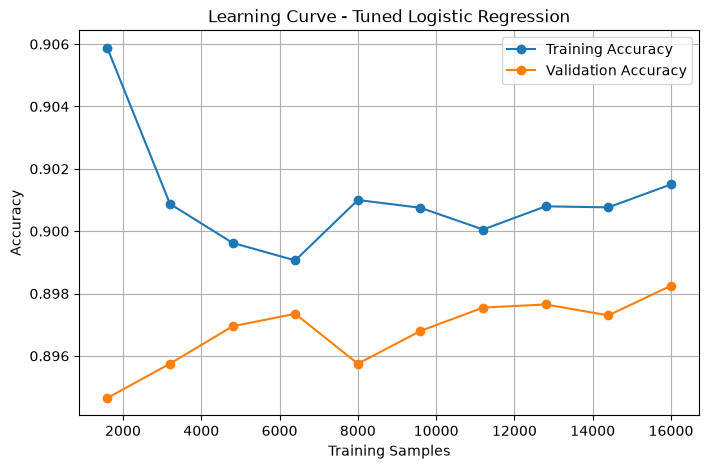

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    lr_tuned_train_sizes,
    lr_tuned_train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    lr_tuned_train_sizes,
    lr_tuned_validation_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")

plt.title("Learning Curve - Tuned Logistic Regression")

plt.legend()
plt.grid()

plt.show()

In [ ]:
lr_cm = confusion_matrix(
    y_test,
    lr_pred
)

print("Logistic Regression Confusion Matrix:")
print(lr_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lr_pred
    )
)

print(
    "\nROC-AUC:",
    roc_auc_score(
        y_test,
        lr_probability
    )
)

Logistic Regression Confusion Matrix:
[[3381  285]
 [ 251 1083]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3666
           1       0.79      0.81      0.80      1334

    accuracy                           0.89      5000
   macro avg       0.86      0.87      0.86      5000
weighted avg       0.89      0.89      0.89      5000


ROC-AUC: 0.9668995289589247


In [12]:
# Save the selected XGBoost hyperparameters
# for the final modeling notebook

xgb_best_params = xgb_grid.best_params_

print("Selected XGBoost parameters:")
print(xgb_best_params)

joblib.dump(
    xgb_best_params,
    "../models/xgboost_best_params.pkl"
)

# Also save the complete GridSearch results
# for reproducibility and later reporting

xgb_grid_results = pd.DataFrame(
    xgb_grid.cv_results_
)

xgb_grid_results.to_csv(
    "../reports/xgboost_grid_search_results.csv",
    index=False
)

print("\nXGBoost parameters and GridSearch results saved.")

Selected XGBoost parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

XGBoost parameters and GridSearch results saved.
